# Homework12

Exercises with Neural Networks

## Goals

- Get familiar with neural network setup, design, data preparation and training process
- Practice setting up the ingredients and parameters for the training loop
- Experiment with neural networks for classification tasks


### Setup

Run the following 2 cells to import all necessary libraries and helpers for this homework

In [1]:
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2026S-A/5020-utils/raw/main/src/nn_utils.py
!wget -qO- https://github.com/PSAM-5020-2026S-A/5020-utils/releases/latest/download/imagenette.tar.gz | tar xz

In [2]:
from os import listdir
from PIL import Image as PImage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from torch import nn, Tensor
from torch.optim import Adagrad, Adam, SGD

from data_utils import classification_error, display_confusion_matrix
from image_utils import get_pixels

from nn_utils import get_labels, get_num_params

## Neural Networks and Classification

We've set up neural networks for regression and classification in the [WK11](https://github.com/PSAM-5020-2026S-A/WK11) and [WK12](https://github.com/PSAM-5020-2026S-A/WK12) notebooks.

The steps for training a neural network are similar to all of the ML processes we've seen so far:
- Data split
- Data pre-preprocessing
- Training/Fitting
- Validation

The specific steps for training a classification network are:

- Load dataset and do any kind of pre-pre-processing (like get pixels and labels for each image)
- Split data into train/test datasets
- Perform any kind of pre-processing (like scaling or encoding)
- Load features and labels into `Tensors`
- Build a NN model
- Set up an optimizer
- Pick a cost/loss function
- Implement an evaluation function and any other kind of visualization that helps quantify/evaluate the model
- Train model
- Evaluate

### Start with the Data

As always, we start with the data. 

We're using the `imagenette` datasets, which is a small subset of the [ImageNet](https://www.image-net.org/) dataset. ImageNet has millions of images and $10\text{,}000$ classes. The `imagenette` subset has about $5\text{,}000$ images that we'll classify into $10$ classes.

The dataset is already split into two directories with training and testing datasets.

The following cell creates file lists for the training and test datasets.

In [3]:
TRAIN_DIR = "./data/image/imagenette/train"
TEST_DIR = "./data/image/imagenette/test"

train_files = sorted(fname for fname in listdir(TRAIN_DIR) if fname.endswith("jpg"))
test_files = sorted(fname for fname in listdir(TEST_DIR) if fname.endswith("jpg"))

### Extract Features

We have to go through the files and extract labels and pixels for each image.

Pixels can be extracted with the `getdata()` function of `PIL.Image` objects or the `get_pixels()` function from our `image_utils` library.

The images are in color. We can either convert them to grayscale, or extract $3$ separate images, one from each channel, and then combine them sequentially. The `img.split()` function might help with the second strategy.

The label for each file can be extracted by reading the first item after splitting the filename on `_`.

These eventually have to be encoded into whole numbers.

In [11]:
# TODO: extract pixels
from PIL import Image
from os.path import join
import numpy as np

IMG_SIZE = (64, 64)

train = {
    "pixels": [],
    "labels": []
}

test = {
    "pixels": [],
    "labels": []
}

train_label_names = [fname.split("_")[0] for fname in train_files]
test_label_names = [fname.split("_")[0] for fname in test_files]

unique_labels = sorted(set(train_label_names))
label_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_label = {i: label for label, i in label_to_id.items()}


# TODO: extract labels
for fname in train_files:
    img = Image.open(join(TRAIN_DIR, fname)).convert("RGB")
    img = img.resize(IMG_SIZE)

    pixels = np.array(img).flatten() / 255.0
    label_name = fname.split("_")[0]
    label_id = label_to_id[label_name]

    train["pixels"].append(pixels)
    train["labels"].append(label_id)


for fname in test_files:
    img = Image.open(join(TEST_DIR, fname)).convert("RGB")
    img = img.resize(IMG_SIZE)

    pixels = np.array(img).flatten() / 255.0
    label_name = fname.split("_")[0]
    label_id = label_to_id[label_name]

    test["pixels"].append(pixels)
    test["labels"].append(label_id)

train["pixels"] = np.array(train["pixels"])
train["labels"] = np.array(train["labels"])

test["pixels"] = np.array(test["pixels"])
test["labels"] = np.array(test["labels"])

print("train pixels:", train["pixels"].shape)
print("train labels:", train["labels"].shape)
print("test pixels:", test["pixels"].shape)
print("test labels:", test["labels"].shape)
print("label_to_id:", label_to_id)

train pixels: (3000, 12288)
train labels: (3000,)
test pixels: (1500, 12288)
test labels: (1500,)
label_to_id: {'chainsaw': 0, 'church': 1, 'dog': 2, 'fish': 3, 'golf': 4, 'horn': 5, 'parachute': 6, 'pump': 7, 'soundsystem': 8, 'truck': 9}


### Tensor It !

Once we have `pixel` and `label` lists, we can create our `Tensor` objects.

Here we're casting label `Tensor`s to `long()` to convert them to whole numbers instead of keeping them as floats.

In [13]:
x_train = Tensor(train["pixels"])
y_train = Tensor(train["labels"]).long()

x_test = Tensor(test["pixels"])
y_test = Tensor(test["labels"]).long()

len(x_train), len(x_test), x_train.shape, x_test.shape

(3000, 1500, torch.Size([3000, 12288]), torch.Size([1500, 12288]))

### Let's train !

Let's create a single layer neural network, like the first one from class, and train it with the training data.

In addition to the actual model/network, we also need an optimizer and a loss function.

In [15]:
# TODO: Create the model and optimizer, the loss function is already defined
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

input_size = x_train.shape[1]                  
num_classes = len(np.unique(train["labels"]))  

model = nn.Linear(input_size, num_classes)

optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

### Question

<span style="color:hotpink;">
How many parameters does your model have?<br>
How many input features does the model have?<br>
How many output features?<br>
</span>

<span style="color:hotpink;">The model has 122,890 parameters. The model has 12,288 input features. The model has 10 output features.</span>

### The Loop

Create a training loop like we saw in class.

This loop should:
- Predict classes by feeding all of the inputs into the `model`
- Measure `loss` (this is just `loss_fn(predicted, actual)`)
- Get the optimizer to back-propagate and annotate the neurons
- Update parameters

The loop should be repeated as long as the loss keeps improving, and it doesn't look like the model is overfitting with the training data.

In order to check if the model is overfitting, we can sporadically run evaluations within the training loop in order to see if the model performs similarly with `train` and `test` data.

But ! Our network actually outputs a series of values for each image that we give it. In order to determine the exact class number of its predictions, we have to find the index of the output neuron with the largest value, which is an operation called `argmax()` (similar to `argsort()` from week 10).

It's not hard to do this manually, but we can use the `get_labels(model, inputs)` function inside the `nn_utils` file to run our `model` on all of the data in a given dataset and return the predicted labels for all of the samples.

In [16]:
# TODO: iterate epochs
epochs = 100

train_losses = []
test_losses = []

for epoch in range(epochs):
  # TODO: predict
  predicted = model(x_train)

  # TODO: measure loss
  loss = loss_fn(predicted, y_train)

  # TODO: compute gradient and step optimizer
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  train_losses.append(loss.item())
  
  # TODO: show progress
  if epoch % 10 == 0:
        with torch.no_grad():
            train_predicted = model(x_train)
            test_predicted = model(x_test)

            train_loss = loss_fn(train_predicted, y_train)
            test_loss = loss_fn(test_predicted, y_test)

            train_labels_predicted = torch.argmax(train_predicted, dim=1)
            test_labels_predicted = torch.argmax(test_predicted, dim=1)

            train_accuracy = (train_labels_predicted == y_train).float().mean()
            test_accuracy = (test_labels_predicted == y_test).float().mean()

            test_losses.append(test_loss.item())

        print(
            "epoch:", epoch,
            "train loss:", train_loss.item(),
            "test loss:", test_loss.item(),
            "train accuracy:", train_accuracy.item(),
            "test accuracy:", test_accuracy.item()
        )


epoch: 0 train loss: 6.430078029632568 test loss: 6.3734893798828125 train accuracy: 0.11299999803304672 test accuracy: 0.1120000034570694
epoch: 10 train loss: 4.060760498046875 test loss: 4.229217052459717 train accuracy: 0.18199999630451202 test accuracy: 0.18066667020320892
epoch: 20 train loss: 2.456157684326172 test loss: 2.564718723297119 train accuracy: 0.26866665482521057 test accuracy: 0.257999986410141
epoch: 30 train loss: 2.1814346313476562 test loss: 2.304584264755249 train accuracy: 0.3063333332538605 test accuracy: 0.2680000066757202
epoch: 40 train loss: 1.9112348556518555 test loss: 2.0352377891540527 train accuracy: 0.34833332896232605 test accuracy: 0.29733332991600037
epoch: 50 train loss: 1.84178626537323 test loss: 1.983377456665039 train accuracy: 0.3813333213329315 test accuracy: 0.3166666626930237
epoch: 60 train loss: 1.7637407779693604 test loss: 1.9289315938949585 train accuracy: 0.4339999854564667 test accuracy: 0.3440000116825104
epoch: 70 train loss: 1.7

### Evaluate

This should be similar to the last error values seen during training, but sometimes it changes a bit...

Not a bad idea to check the accuracy of the model using the `classification_error()` function, and look at some confusion matrices.

Train accuracy: 0.49566665291786194
Test accuracy: 0.3513333201408386
Train classification error: 0.5043333470821381
Test classification error: 0.6486666798591614


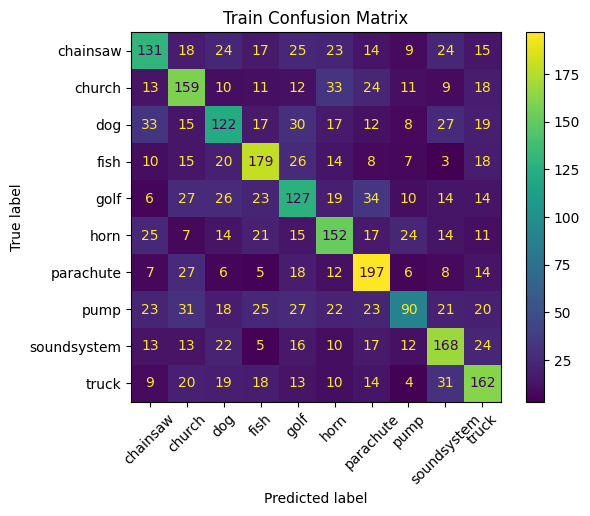

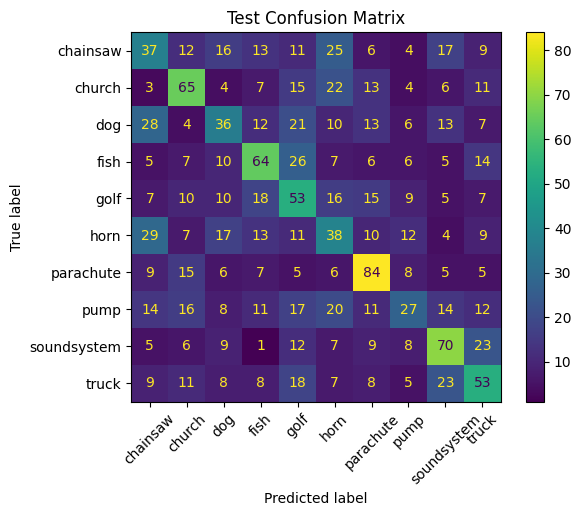

In [17]:
# TODO: classification error for train and test data
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

with torch.no_grad():
    train_outputs = model(x_train)
    test_outputs = model(x_test)

    train_pred = torch.argmax(train_outputs, dim=1)
    test_pred = torch.argmax(test_outputs, dim=1)

train_accuracy = (train_pred == y_train).float().mean().item()
test_accuracy = (test_pred == y_test).float().mean().item()

train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)
print("Train classification error:", train_error)
print("Test classification error:", test_error)

# TODO: confusion matrices for train and test data
class_names = [id_to_label[i] for i in range(num_classes)]

train_cm = confusion_matrix(y_train.numpy(), train_pred.numpy())

disp = ConfusionMatrixDisplay(
    confusion_matrix=train_cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Train Confusion Matrix")
plt.show()

test_cm = confusion_matrix(y_test.numpy(), test_pred.numpy())

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=class_names
)

disp.plot(xticks_rotation=45)
plt.title("Test Confusion Matrix")
plt.show()

### Interpretation

<span style="color:hotpink;">
What's going on ? Is the network learning ?
</span>

<span style="color:hotpink;">The network is learning, but not very strongly. The loss decreases over time, and the diagonal cells in the confusion matrices are generally higher than the other cells, which means the model is predicting some classes correctly. However, the test accuracy is still much lower than the training accuracy, so the model does not generalize very well. It seems to be learning some patterns from the training data, but because this is only a single-layer network using raw pixels, it still confuses many classes.</span>

## Neural Networks and PCA

We are seeing how Neural Networks can be _easy_ to build and explain in generic/abstract terms (a bunch of little operators that perform weighted sums of their inputs), but in reality can be really difficult and opaque to steer.

In theory, a couple of well placed neuron layers, with the right hyperparameters, learning rate, loss function, architecture and a good amount of data, can learn to extract information like polynomial features, clusters or even PCA components. But... that's not always the case and sometimes it's not a bad idea to *encourage* the network to go down a certain path.

One way to do this is to pre-process our inputs and do a bit of feature extraction ourselves.

Let's see if we can improve this classification network by using PCA information instead of pixel data.

### Add PCA

We're going to repeat the training, but this time our data is going to be scaled and PCA'd before going into the neural network.

So, the data preparation flow should be:
- Scale data for `PCA`
- Perform `PCA`

We need one `StandardScaler()` object and one `PCA()` object.

The `train` data goes through the `fit_transform()` function of these objects, while the `test` data only goes through `transform()`.

For the `PCA`, we can aim for an explained variance of around $80\%$. This should reduce the number of features significantly to allow us to experiment with our network architecture.

We're working with a dataset that is $3\text{,}000$ rows by $49\text{,}152$ columns. Fitting `PCA` can take a minute.

In [18]:
# TODO: Scale
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from torch import Tensor
import torch

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train["pixels"])
test_scaled = scaler.transform(test["pixels"])

# TODO: PCA
pca = PCA(n_components=0.80, svd_solver="full")
train_pca = pca.fit_transform(train_scaled)
test_pca = pca.transform(test_scaled)

# TODO: Tensors
x_train = Tensor(train_pca).float()
x_test = Tensor(test_pca).float()

y_train = Tensor(train["labels"]).long()
y_test = Tensor(test["labels"]).long()


print("Original train shape:", train["pixels"].shape)
print("PCA train shape:", x_train.shape)

print("Original test shape:", test["pixels"].shape)
print("PCA test shape:", x_test.shape)

print("Explained variance:", pca.explained_variance_ratio_.sum())
print("Number of PCA components:", pca.n_components_)

Original train shape: (3000, 12288)
PCA train shape: torch.Size([3000, 69])
Original test shape: (1500, 12288)
PCA test shape: torch.Size([1500, 69])
Explained variance: 0.8000830938942481
Number of PCA components: 69


### Repeat

Re-create model, optimizer, loss function, then re-run the training loop and evaluate.

In [19]:
# TODO: Model, Optimizer and Loss Function
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

input_size = x_train.shape[1]         
num_classes = len(np.unique(train["labels"]))
model = nn.Linear(input_size, num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
print("input size:", input_size)
print("num classes:", num_classes)
print("model:", model)

# TODO: Training loop
epochs = 100

for epoch in range(epochs):

    predicted = model(x_train)

    loss = loss_fn(predicted, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        with torch.no_grad():
            train_outputs = model(x_train)
            test_outputs = model(x_test)

            train_loss = loss_fn(train_outputs, y_train)
            test_loss = loss_fn(test_outputs, y_test)

            train_pred = torch.argmax(train_outputs, dim=1)
            test_pred = torch.argmax(test_outputs, dim=1)

            train_accuracy = (train_pred == y_train).float().mean()
            test_accuracy = (test_pred == y_test).float().mean()

        print(
            "epoch:", epoch,
            "train loss:", train_loss.item(),
            "test loss:", test_loss.item(),
            "train accuracy:", train_accuracy.item(),
            "test accuracy:", test_accuracy.item()
        )

# TODO: Evaluation
model.eval()

with torch.no_grad():
    train_outputs = model(x_train)
    test_outputs = model(x_test)

    train_pred = torch.argmax(train_outputs, dim=1)
    test_pred = torch.argmax(test_outputs, dim=1)

train_accuracy = (train_pred == y_train).float().mean().item()
test_accuracy = (test_pred == y_test).float().mean().item()

train_error = 1 - train_accuracy
test_error = 1 - test_accuracy

print("Final train accuracy:", train_accuracy)
print("Final test accuracy:", test_accuracy)
print("Train classification error:", train_error)
print("Test classification error:", test_error)

input size: 69
num classes: 10
model: Linear(in_features=69, out_features=10, bias=True)
epoch: 0 train loss: 9.735368728637695 test loss: 9.761202812194824 train accuracy: 0.10433333367109299 test accuracy: 0.10266666859388351
epoch: 10 train loss: 8.317045211791992 test loss: 8.458215713500977 train accuracy: 0.12866666913032532 test accuracy: 0.11800000071525574
epoch: 20 train loss: 7.0695085525512695 test loss: 7.29618501663208 train accuracy: 0.16200000047683716 test accuracy: 0.14266666769981384
epoch: 30 train loss: 5.991602420806885 test loss: 6.269528865814209 train accuracy: 0.17933332920074463 test accuracy: 0.15933333337306976
epoch: 40 train loss: 5.045312404632568 test loss: 5.34605073928833 train accuracy: 0.20133332908153534 test accuracy: 0.1706666648387909
epoch: 50 train loss: 4.213082790374756 test loss: 4.522063255310059 train accuracy: 0.21799999475479126 test accuracy: 0.18333333730697632
epoch: 60 train loss: 3.5021066665649414 test loss: 3.811919689178467 trai

### Interpretation

<span style="color:hotpink;">
So... What happens ?<br>
How does training on the <code>PCA</code> data compare to training on the regular data ?

What else does <code>PCA</code> afford us in this case ? ...<br>
How does adding extra layers in the original network compare to adding extra layers in the <code>PCA</code> network?
</span>

<span style="color:hotpink;"> Training on the PCA data reduced the number of input features from 12,288 to 69, so the model became much smaller and simpler. However, the performance was lower than the regular pixel model. The regular model reached about 35% test accuracy, while the PCA model reached about 28%. PCA makes the network faster and easier to train because it removes many raw pixel features while keeping about 80% of the variance. However, it may also remove details that are useful for classification.
Adding extra layers to the original network would create many more parameters because the input size is very large. Adding extra layers to the PCA network is more affordable because the input size is much smaller, so we can experiment with deeper networks more easily.</span>